## Variable selection for h5 files over a range of rensonance-masses

### *BulkGrav reco-analysis*

### *–––– Set up ––––*

In [7]:
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import hist
import hist.dask as hda
import dask
import coffea.processor as processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import vector
import json
import pandas as pd

NanoAODSchema.warn_missing_crossrefs = False

In [8]:
with open("samples.json", 'r') as f:
    fileset = json.load(f)

# pick out only the Bulk keys
bulk_samples = [name for name in fileset if name.startswith("BulkGravToWW")]

### *––– Helper Functions –––*

In [9]:
# -- Subjet Pair Extraction for Semi-Leptonic Events --
def extract_semi_subjet_pairs(fatjets, all_subjets, category_name="Semi-Leptonic"):
    pairs = []
    n_skipped = 0

    for event_fjs, event_sjs in zip(fatjets, all_subjets):
        if len(event_fjs) == 0:
            continue
        fj = event_fjs[0]
        try:
            idx1, idx2 = fj.subJetIdx1, fj.subJetIdx2
            if idx1 < 0 or idx2 < 0:
                raise ValueError("Invalid subjet indices")

            sj1, sj2 = event_sjs[idx1], event_sjs[idx2]
            vec1 = vector.obj(pt=sj1["pt"], eta=sj1["eta"], phi=sj1["phi"], mass=sj1["mass"])
            vec2 = vector.obj(pt=sj2["pt"], eta=sj2["eta"], phi=sj2["phi"], mass=sj2["mass"])
            pairs.append((vec1, vec2))
        except (KeyError, TypeError, ValueError):
            n_skipped += 1

    print(f"[{category_name}] Valid subjet pairs: {len(pairs)}, Skipped: {n_skipped}")
    return pairs

# -- Subjet Pair Extraction for Hadronic Events --
def extract_had_subjet_pairs(fatjets, category_name="Hadronic"):
    valid_pairs = []
    n_skipped = 0

    for subjets in fatjets.subjets:
        if len(subjets) < 2:
            n_skipped += 1
            continue
        try:
            sj1, sj2 = subjets[0], subjets[1]
            vec1 = vector.obj(pt=sj1["pt"], eta=sj1["eta"], phi=sj1["phi"], mass=sj1["mass"])
            vec2 = vector.obj(pt=sj2["pt"], eta=sj2["eta"], phi=sj2["phi"], mass=sj2["mass"])
            valid_pairs.append((vec1, vec2))
        except (KeyError, TypeError, ValueError):
            n_skipped += 1

    print(f"[{category_name}] Valid subjet pairs: {len(valid_pairs)}, Skipped: {n_skipped}")
    return valid_pairs

In [10]:
# -- Compute cos(θ*) for Given Subjet Pairs --
def compute_cos_theta_star_from_vectors(subjet_pairs, category_name=""):
    cos_theta_star = []
    n_success = 0
    n_skipped = 0

    for i, (vec1, vec2) in enumerate(subjet_pairs):
        # 1) Reconstruct the W four-vector in the lab frame
        w_lab = vec1 + vec2
        if w_lab.mass < 1e-3 or w_lab.E <= 1e-6:
            n_skipped += 1

        # 2) Build the boost to the W rest frame
        beta3 = -w_lab.to_beta3()
        if beta3.mag < 1e-6:
            n_skipped += 1
            continue
        
        # 3) RAPIDITY SORT: pick the subjet that’s more “backward” in η
        #    (this ensures the dot can go negative when it should)
        if vec1.rapidity < vec2.rapidity:
            q = vec1  
        else:
            q = vec2

        # 4) Boost that chosen subjet into the W rest frame
        q_rest = q.boost_beta3(beta3)
        if q_rest.to_beta3().mag < 1e-6:
            n_skipped += 1
            continue

        # 5) Compute signed cosθ* via vector’s unit-vector dot        
        w_hat  = w_lab.to_beta3().unit()
        q_hat  = q_rest.to_beta3().unit()
        cos_theta = q_hat.dot(w_hat)

        cos_theta_star.append(cos_theta)
        n_success += 1

    if len(cos_theta_star) > 0:
            cos_array = np.array(cos_theta_star)
            print(f"[{category_name}] Computed cosθ* for {n_success} subjet pairs, Skipped: {n_skipped}")
            print(f"[{category_name}] range: min = {cos_array.min():.3f}, max = {cos_array.max():.3f}")
            print(f"[{category_name}] Histogram counts (neg, zero, pos): "
                  f"{np.sum(cos_array < 0)}, {np.sum(cos_array == 0)}, {np.sum(cos_array > 0)}")
    return np.array(cos_theta_star)

### *–––main–––*

In [13]:
for sample_name in bulk_samples:

    # ––– STEP 0: LOAD EVENTS ––––
    events = NanoEventsFactory.from_root(
        fileset[sample_name]["files"],
        entry_stop=10000,
        metadata=fileset[sample_name]["metadata"],
        schemaclass=NanoAODSchema,
        delayed=False,
    ).events()

    # ––– STEP 1: TIGHT LEPTON SELECTION  –––
    muons = events.Muon
    electrons = events.Electron
    
    muons_tight = muons[
        (muons.pt > 35) & (muons.eta < 2.4) & (muons.tightId) &
        (((muons.pt < 10) & (muons.dxy < 0.01)) | ((muons.pt >= 10) & (muons.dxy < 0.02))) &
        (muons.dz < 0.05) & (muons.pfIsoId >= 4)
    ]
    print(f"{len(ak.flatten(muons_tight))} out of {len(ak.flatten(muons))} muons pass the tight selection")
    
    electrons_tight = electrons[
        (electrons.pt > 30) & (electrons.eta < 2.4) & (((electrons.pt < 15) & 
        (electrons.dxy < 0.01)) | ((electrons.pt >= 15) & 
        (electrons.dxy < 0.02))) & (electrons.dxy < 0.05) & # dxy tighter (electrons.dz < 0.05) &
        (electrons.pfRelIso03_all < 0.15) & (electrons.lostHits <= 1) & (electrons.convVeto == True)
    ]
    print(f"{ len(ak.flatten(electrons_tight))} out of {len(ak.flatten(electrons))} electrons pass the tight selection")
    
    tight_muon_count = ak.num(muons_tight)
    tight_electron_count = ak.num(electrons_tight)
    loose_muons = muons[(muons.isPFcand) & (muons.mediumId) & (muons.pfRelIso03_all < 0.4)]
    loose_muons = loose_muons[loose_muons.pt > 10]
    loose_electrons = electrons[electrons.cutBased >= 2]
    loose_electrons = loose_electrons[loose_electrons.pt > 10]
    loose_lepton_count = ak.num(loose_muons) + ak.num(loose_electrons)
    
    single_lepton_mask = ((tight_muon_count + tight_electron_count) == 1) & (loose_lepton_count == 1)
    events_selected = events[single_lepton_mask]
    
    print(f"{len(events_selected)} events {len(events)} passed the tight lepton selection and loose veto.")

    # Masks for exactly one tight lepton
    one_tight_electron_mask = (tight_electron_count == 1) & (tight_muon_count == 0) & (loose_lepton_count == 1)
    one_tight_muon_mask = (tight_muon_count == 1) & (tight_electron_count == 0) & (loose_lepton_count == 1)
    
    # Apply masks to original tight collections
    tight_electron_one = electrons_tight[one_tight_electron_mask]
    tight_muon_one = muons_tight[one_tight_muon_mask]

    # ––– STEP 2: AK8 CLEANING –––
    # FatJets cuts
    clean_fatJets = events.FatJet[(events.FatJet.pt > 150) & (events.FatJet.eta < 2.4) & (events.FatJet.msoftdrop > 0)]
    #Jets cuts
    clean_Jets = events.Jet[(events.Jet.pt > 30) & (events.Jet.eta < 4.6)]

    #Removing AK4(Jet) jets overlapping with AK8(FatJets) jets
    jets_fatjets = ak.cartesian({"x": clean_Jets, "y": clean_fatJets})
    jets_iso_f = ((jets_fatjets["x"].eta-jets_fatjets["y"].eta)**2+(jets_fatjets["x"].phi-jets_fatjets["y"].phi)**2>0.8**2)
    jets_fatjets = jets_fatjets[jets_iso_f]
    jets, fj = ak.unzip(jets_fatjets)

    # Require events with at least 1 clean AK8 FatJets
    AK8jets_candidates_mask = ak.num(clean_fatJets) >= 1
    Wjets_candidates = clean_fatJets[AK8jets_candidates_mask]
    leading_W_jet = Wjets_candidates[:, 0]
    leading_W_jet_pt = leading_W_jet.pt

    # Require events with at least  clean AK8 FatJets
    AK8jets_2_mask = ak.num(clean_fatJets) >= 2
    Wjets_2_candidates = clean_fatJets[AK8jets_2_mask]
    second_W_jet = Wjets_2_candidates[:, 1]
    second_W_jet_pt = second_W_jet.pt

    # ––– STEP 3: EVENT CATEGORIZATION –––
    #tight lepton masks
    n_tight_muons = ak.num(muons_tight)
    n_tight_electrons = ak.num(electrons_tight)
    
    # event masks
    semi_leptonic_mask = (
        ((n_tight_muons == 1) & (n_tight_electrons == 0)) |
        ((n_tight_muons == 0) & (n_tight_electrons == 1))) & (ak.num(clean_fatJets) >= 1)
    
    fully_hadronic_mask = (
        (n_tight_muons == 0) & (n_tight_electrons == 0) &
        (ak.num(clean_fatJets) >= 2))

    # semi-leptonic W decay: 
    semi_leptonic_fatjets = clean_fatJets[semi_leptonic_mask]
    # fully hadronic W decay: 
    fully_hadronic_fatjets = clean_fatJets[fully_hadronic_mask]

    # For plotting (flatten to leading/subleading jets)
    semi_leptonic_leading_jet = semi_leptonic_fatjets[:, 0]
    fully_hadronic_leading_jet = fully_hadronic_fatjets[:, 0]
    fully_hadronic_second_jet = fully_hadronic_fatjets[:, 1]

    # STEP 4: COMPUTE cosθ* FOR EACH CATEGORY –––
    semi_pairs = extract_semi_subjet_pairs(semi_leptonic_fatjets, events.SubJet[semi_leptonic_mask], "Semi-Leptonic")
    had1_pairs = extract_had_subjet_pairs(fully_hadronic_leading_jet, "Hadronic Lead")
    had2_pairs = extract_had_subjet_pairs(fully_hadronic_second_jet, "Hadronic Sublead")

    cos_theta_semi = compute_cos_theta_star_from_vectors(semi_pairs, "Semi-Leptonic")
    cos_theta_had1 = compute_cos_theta_star_from_vectors(had1_pairs, "Hadronic Lead")
    cos_theta_had2 = compute_cos_theta_star_from_vectors(had2_pairs, "Hadronic Sublead")

    # 6) BUILD & SAVE DATAFRAME
    df = pd.DataFrame({
        # semi-leptonic jet features
        "pt_semi":      ak.to_numpy(semi_leptonic_leading_jet.pt),
        "eta_semi":     ak.to_numpy(semi_leptonic_leading_jet.eta),
        "msoft_semi":   ak.to_numpy(semi_leptonic_leading_jet.msoftdrop),
        "cos__theta_semi":     cos_theta_semi,

        # fully-hadronic leading jet features
        "pt_h1":        ak.to_numpy(fully_hadronic_leading_jet.pt),
        "eta_h1":       ak.to_numpy(fully_hadronic_leading_jet.eta),
        "msoft_h1":     ak.to_numpy(fully_hadronic_leading_jet.msoftdrop),
        "cos_theta_h1":       cos_theta_had1,

        # fully-hadronic subleading jet features
        "pt_h2":        ak.to_numpy(fully_hadronic_second_jet.pt),
        "eta_h2":       ak.to_numpy(fully_hadronic_second_jet.eta),
        "msoft_h2":     ak.to_numpy(fully_hadronic_second_jet.msoftdrop),
        "cos_theta_h2":       cos_theta_had2,

        # sample label for ML (Bulk = 1 longitudinal)
        "label":       np.ones_like(ak.to_numpy(had_fj1.pt), dtype=int),
    })

    outname = f"{sample_name}_features.h5"
    df.to_hdf(outname, key="df", mode="w")
    print(f"Wrote {outname} ({len(df)} events)")

2294 out of 6848 muons pass the tight selection
2362 out of 8876 electrons pass the tight selection
3390 events 10000 passed the tight lepton selection and loose veto.
[Semi-Leptonic] Valid subjet pairs: 3051, Skipped: 483
[Hadronic Lead] Valid subjet pairs: 5006, Skipped: 20
[Hadronic Sublead] Valid subjet pairs: 4929, Skipped: 97
[Semi-Leptonic] Computed cosθ* for 3051 subjet pairs, Skipped: 0
[Semi-Leptonic] range: min = -0.929, max = 0.855
[Semi-Leptonic] Histogram counts (neg, zero, pos): 1514, 0, 1537
[Hadronic Lead] Computed cosθ* for 5006 subjet pairs, Skipped: 0
[Hadronic Lead] range: min = -0.909, max = 0.873
[Hadronic Lead] Histogram counts (neg, zero, pos): 2483, 0, 2523
[Hadronic Sublead] Computed cosθ* for 4929 subjet pairs, Skipped: 0
[Hadronic Sublead] range: min = -0.878, max = 0.931
[Hadronic Sublead] Histogram counts (neg, zero, pos): 2481, 0, 2448


NameError: name 'semi_fj' is not defined

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_206/1336518847.py:4: SyntaxWarning: invalid escape sequence '\e'
  "eta": ("Jet $\eta$", (-3, 3), lambda jet: jet.eta),


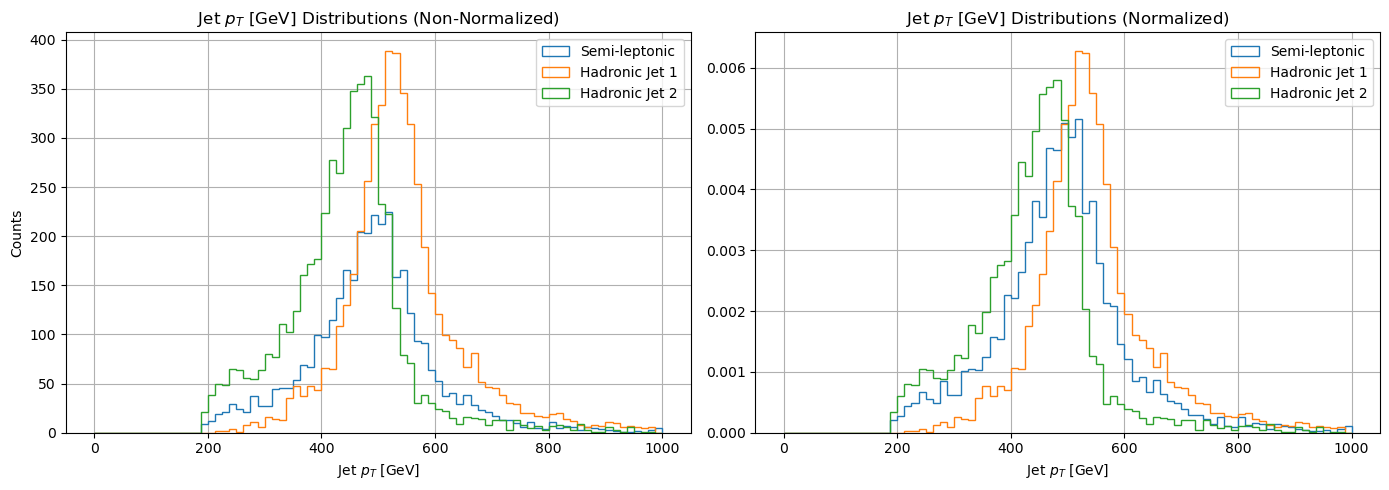

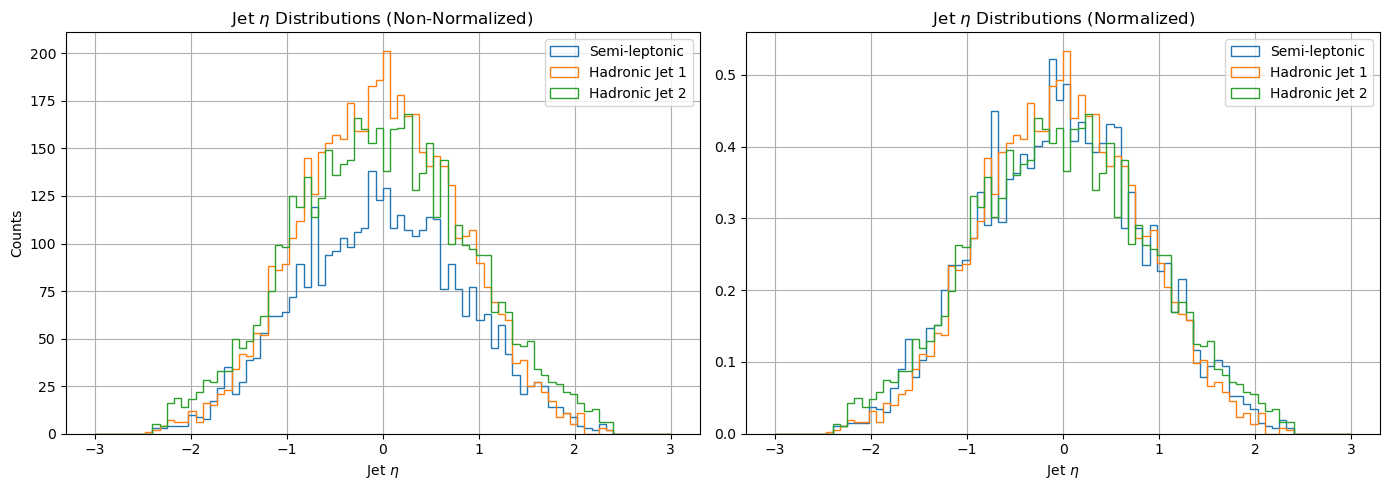

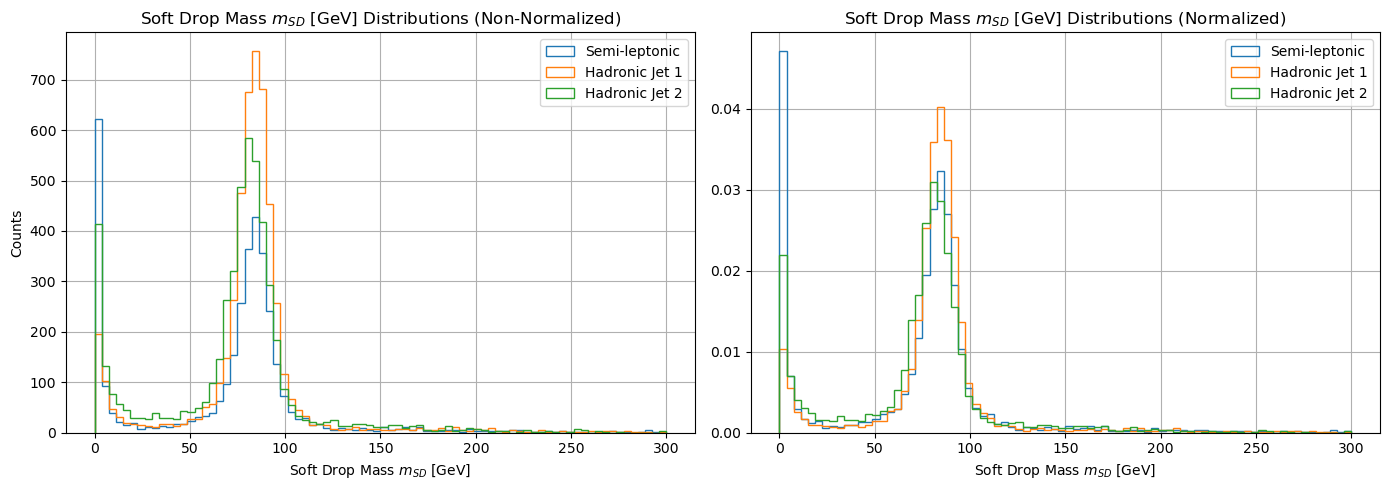

In [14]:
# dict mapping jet properties to axis labels, plot ranges, and access functions
jet_sets = {
    "pt": ("Jet $p_T$ [GeV]", (0, 1000), lambda jet: jet.pt),
    "eta": ("Jet $\eta$", (-3, 3), lambda jet: jet.eta),
    "msoftdrop": ("Soft Drop Mass $m_{SD}$ [GeV]", (0, 300), lambda jet: jet.msoftdrop)
}
# loop over each jet parameter to generate plots
for key, (xlabel, rng, accessor) in jet_sets.items():
    plt.figure(figsize=(14, 5))
    
    # left: non-normalized
    plt.subplot(1, 2, 1)
    plt.hist(ak.to_numpy(accessor(semi_leptonic_leading_jet)), bins=80, range=rng,
             histtype='step', label='Semi-leptonic')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_leading_jet)), bins=80, range=rng,
             histtype='step', label='Hadronic Jet 1')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_second_jet)), bins=80, range=rng,
             histtype='step', label='Hadronic Jet 2')
    plt.title(f"{xlabel} Distributions (Non-Normalized)")
    plt.xlabel(xlabel)
    plt.ylabel("Counts")
    plt.legend()
    plt.grid(True)

    # right: normalized
    plt.subplot(1, 2, 2)
    plt.hist(ak.to_numpy(accessor(semi_leptonic_leading_jet)), bins=80, range=rng,
             density=True, histtype='step', label='Semi-leptonic')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_leading_jet)), bins=80, range=rng,
             density=True, histtype='step', label='Hadronic Jet 1')
    plt.hist(ak.to_numpy(accessor(fully_hadronic_second_jet)), bins=80, range=rng,
             density=True, histtype='step', label='Hadronic Jet 2')
    plt.title(f"{xlabel} Distributions (Normalized)")
    plt.xlabel(xlabel)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()